In [92]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [21]:
df = pd.read_csv("/content/drive/MyDrive/Customer Churn/Dataset/processed/telco_clean.csv")
print("Shape :", df.shape)

df.head()

Shape : (7043, 22)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,1


In [22]:
print("=" * 60)

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("\nTarget Distribution")

print(df["Churn"].value_counts())

print("=" * 60)

Missing Values : 0
Duplicate Rows : 22

Target Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [23]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (7043, 21)
Target Shape : (7043,)


In [24]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'IsNewCustomer']

Categorical Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("=" * 60)
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)
print("=" * 60)

Training Set : (5634, 21)
Testing Set  : (1409, 21)


In [26]:
# @title
train_dist = (
    y_train.value_counts(normalize=True)
    .rename("Train")
    * 100
)

test_dist = (
    y_test.value_counts(normalize=True)
    .rename("Test")
    * 100
)

distribution = pd.concat([train_dist, test_dist], axis=1)

display(distribution.round(2))

,Train,Test
Churn,,
0,73.46,73.46
1,26.54,26.54


In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training Shape :", X_train_processed.shape)
print("Testing Shape  :", X_test_processed.shape)

Training Shape : (5634, 32)
Testing Shape  : (1409, 32)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [30]:
results = []

for name, model in models.items():

    # Build Pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [31]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.664430,0.529412,0.589286,0.845984
1,XGBoost,0.792051,0.627760,0.532086,0.575977,0.826362
2,Random Forest,0.789922,0.636364,0.486631,0.551515,0.824662
3,Decision Tree,0.730305,0.491525,0.465241,0.478022,0.645147


In [32]:
display(
    results_df.style
    .background_gradient(cmap="Greens")
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8041,0.6644,0.5294,0.5893,0.8460
1,XGBoost,0.7921,0.6278,0.5321,0.5760,0.8264
2,Random Forest,0.7899,0.6364,0.4866,0.5515,0.8247
3,Decision Tree,0.7303,0.4915,0.4652,0.4780,0.6451


In [33]:
trained_pipelines = {}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [34]:
best_pipeline = trained_pipelines["Logistic Regression"]

print(best_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'ServiceCount',
                                                   'IsNewCustomer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                         

In [35]:
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

len(feature_names)

32

In [36]:
coefficients = best_pipeline.named_steps[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,Absolute
27,cat__Contract_Two year,-1.471804,1.471804
12,cat__InternetService_Fiber optic,1.236934,1.236934
26,cat__Contract_One year,-0.695009,0.695009
1,num__tenure,-0.675689,0.675689
15,cat__OnlineSecurity_Yes,-0.474697,0.474697
9,cat__PhoneService_Yes,-0.444489,0.444489
21,cat__TechSupport_Yes,-0.433834,0.433834
11,cat__MultipleLines_Yes,0.418941,0.418941
2,num__MonthlyCharges,-0.411123,0.411123
28,cat__PaperlessBilling_Yes,0.387376,0.387376


In [37]:
display(coef_df.head(15))

,Feature,Coefficient,Absolute
27,cat__Contract_Two year,-1.471804,1.471804
12,cat__InternetService_Fiber optic,1.236934,1.236934
26,cat__Contract_One year,-0.695009,0.695009
1,num__tenure,-0.675689,0.675689
15,cat__OnlineSecurity_Yes,-0.474697,0.474697
9,cat__PhoneService_Yes,-0.444489,0.444489
21,cat__TechSupport_Yes,-0.433834,0.433834
11,cat__MultipleLines_Yes,0.418941,0.418941
2,num__MonthlyCharges,-0.411123,0.411123
28,cat__PaperlessBilling_Yes,0.387376,0.387376


In [38]:
positive_coef = (
    coef_df
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

positive_coef

,Feature,Coefficient,Absolute
12,cat__InternetService_Fiber optic,1.236934,1.236934
11,cat__MultipleLines_Yes,0.418941,0.418941
28,cat__PaperlessBilling_Yes,0.387376,0.387376
30,cat__PaymentMethod_Electronic check,0.350989,0.350989
4,num__ServiceCount,0.311727,0.311727
5,num__IsNewCustomer,0.300787,0.300787
25,cat__StreamingMovies_Yes,0.258108,0.258108
23,cat__StreamingTV_Yes,0.242431,0.242431
3,num__TotalCharges,0.122649,0.122649
0,num__SeniorCitizen,0.055776,0.055776


In [39]:
negative_coef = (
    coef_df
    .sort_values("Coefficient")
    .head(10)
)

negative_coef

,Feature,Coefficient,Absolute
27,cat__Contract_Two year,-1.471804,1.471804
26,cat__Contract_One year,-0.695009,0.695009
1,num__tenure,-0.675689,0.675689
15,cat__OnlineSecurity_Yes,-0.474697,0.474697
9,cat__PhoneService_Yes,-0.444489,0.444489
21,cat__TechSupport_Yes,-0.433834,0.433834
2,num__MonthlyCharges,-0.411123,0.411123
17,cat__OnlineBackup_Yes,-0.262981,0.262981
8,cat__Dependents_Yes,-0.216289,0.216289
10,cat__MultipleLines_No phone service,-0.209186,0.209186


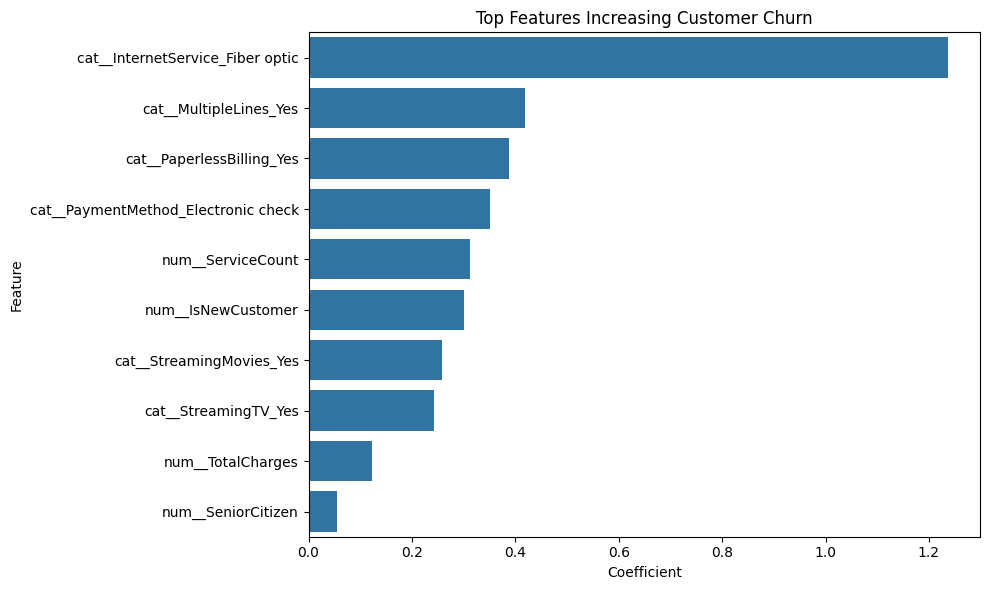

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=positive_coef,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Increasing Customer Churn")

plt.tight_layout()

plt.show()

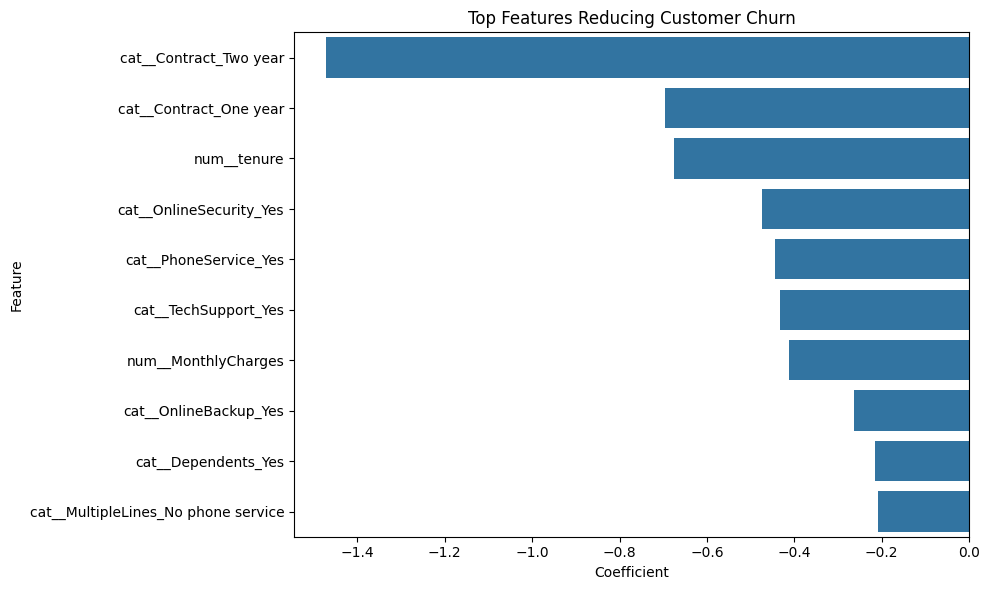

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=negative_coef,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Reducing Customer Churn")

plt.tight_layout()

plt.show()

In [43]:
from sklearn.inspection import permutation_importance

In [44]:
perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [45]:
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df

,Feature,Importance
4,tenure,0.058133
7,InternetService,0.043721
14,Contract,0.037894
17,MonthlyCharges,0.018043
20,IsNewCustomer,0.017375
19,ServiceCount,0.006434
8,OnlineSecurity,0.003774
11,TechSupport,0.003635
6,MultipleLines,0.003336
5,PhoneService,0.003204


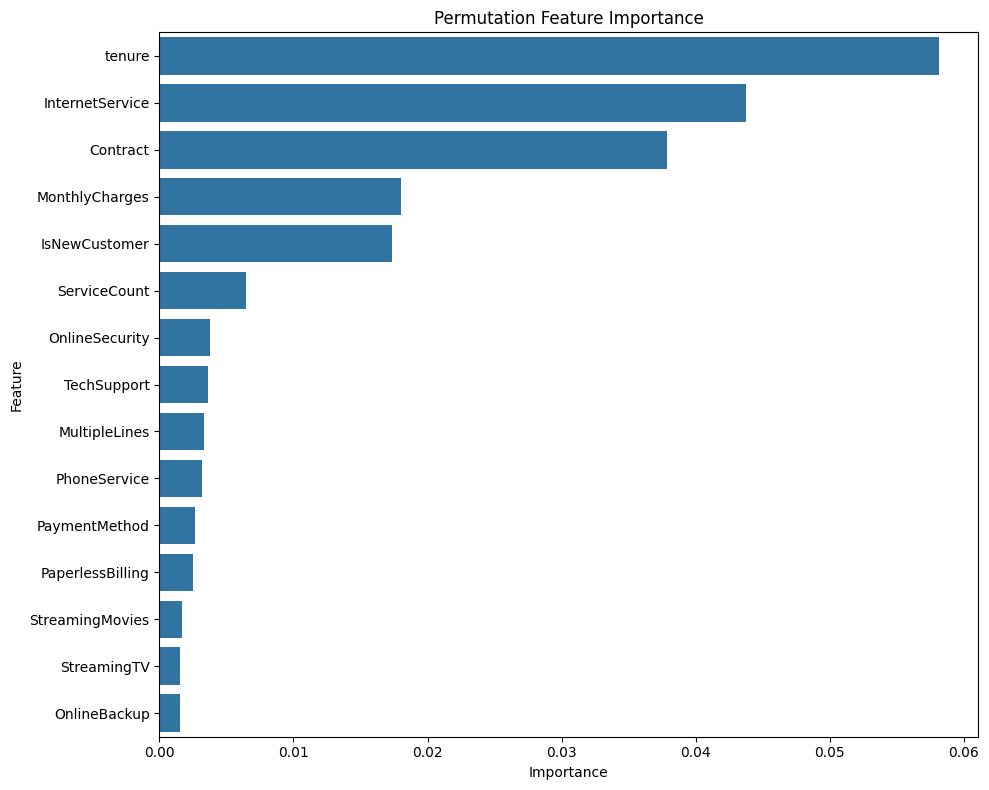

In [46]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=perm_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.show()

In [48]:
best_pipeline = trained_pipelines["Logistic Regression"]

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

<Figure size 600x600 with 0 Axes>

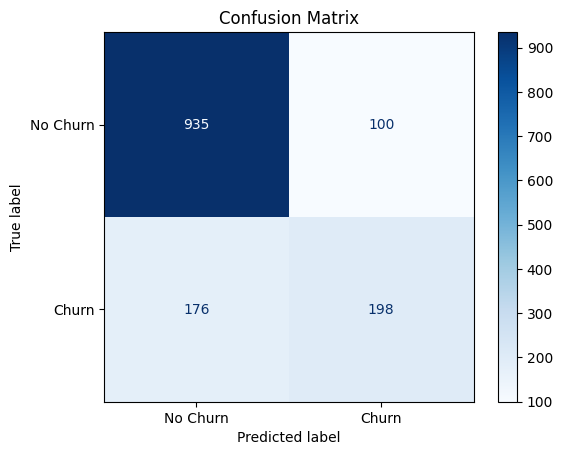

In [49]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [50]:
print("="*70)
print("Classification Report")
print("="*70)

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn","Churn"]
))

Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



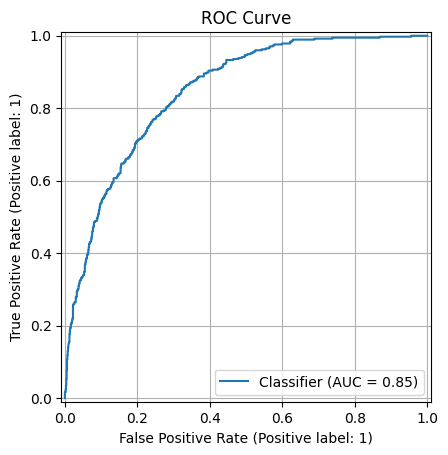

In [51]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.grid(True)
plt.show()

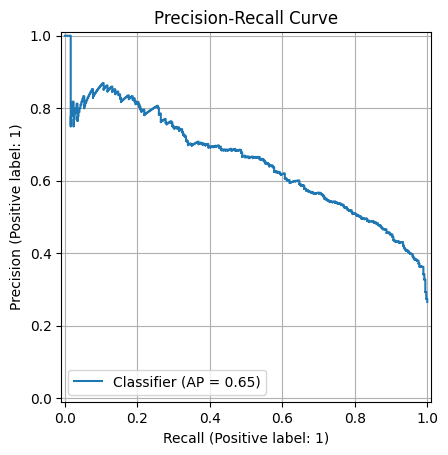

In [52]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

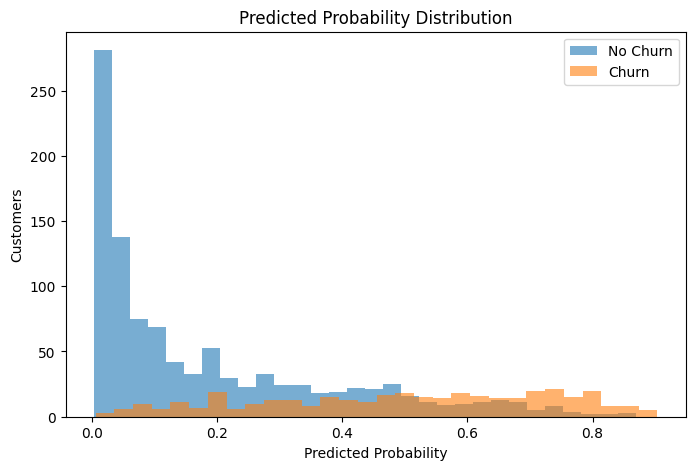

In [53]:
plt.figure(figsize=(8,5))

plt.hist(
    y_prob[y_test == 0],
    bins=30,
    alpha=0.6,
    label="No Churn"
)

plt.hist(
    y_prob[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Churn"
)

plt.xlabel("Predicted Probability")

plt.ylabel("Customers")

plt.title("Predicted Probability Distribution")

plt.legend()

plt.show()

In [64]:
smote_pipeline = ImbPipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("smote", SMOTE(
            random_state=42
        )),

        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))

    ]

)

In [65]:
smote_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'ServiceCount',
                                                   'IsNewCustomer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [66]:
y_pred_smote = smote_pipeline.predict(X_test)

y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("="*70)
print("SMOTE Logistic Regression")
print("="*70)

print(f"Accuracy : {accuracy_score(y_test,y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_smote):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred_smote):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred_smote):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test,y_prob_smote):.4f}")

SMOTE Logistic Regression
Accuracy : 0.7402
Precision: 0.5068
Recall   : 0.7968
F1 Score : 0.6195
ROC AUC  : 0.8438


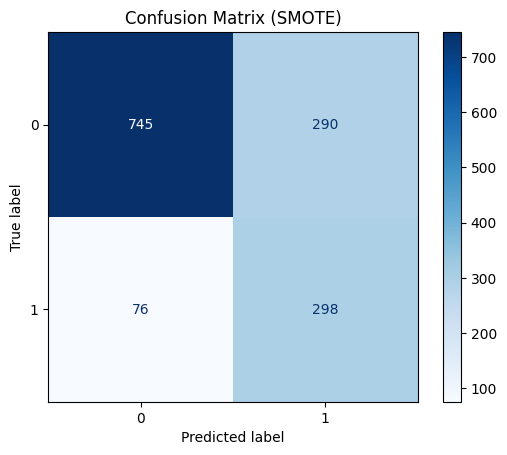

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,
    cmap="Blues"
)

plt.title("Confusion Matrix (SMOTE)")
plt.show()

In [69]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_smote,
    target_names=[
        "No Churn",
        "Churn"
    ]
))

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [70]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ],

    "SMOTE":[
        accuracy_score(y_test,y_pred_smote),
        precision_score(y_test,y_pred_smote),
        recall_score(y_test,y_pred_smote),
        f1_score(y_test,y_pred_smote),
        roc_auc_score(y_test,y_prob_smote)
    ]

})

comparison

,Metric,Baseline,SMOTE
0,Accuracy,0.804116,0.740241
1,Precision,0.664430,0.506803
2,Recall,0.529412,0.796791
3,F1 Score,0.589286,0.619543
4,ROC-AUC,0.845984,0.843845


In [71]:
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

balanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'ServiceCount',
                                                   'IsNewCustomer']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [72]:
y_pred_balanced = balanced_pipeline.predict(X_test)
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:, 1]

In [73]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=[
        "No Churn",
        "Churn"
    ]
))

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [74]:
import numpy as np

print(np.array_equal(y_pred_smote, y_pred_balanced))

False


In [75]:
print(np.max(np.abs(y_prob_smote - y_prob_balanced)))

0.09128632006546558


In [76]:
print("SMOTE")
print(y_pred_smote[:20])

print("\nBalanced")
print(y_pred_balanced[:20])

SMOTE
[0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0]

Balanced
[0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0]


In [77]:
print(np.array_equal(y_pred_smote, y_pred_balanced))

False


In [78]:
different_predictions = np.sum(y_pred_smote != y_pred_balanced)

print("Different Predictions :", different_predictions)

Different Predictions : 20


In [79]:
prob_diff = np.abs(y_prob_smote - y_prob_balanced)

print("Average Probability Difference :", prob_diff.mean())
print("Maximum Probability Difference :", prob_diff.max())

Average Probability Difference : 0.015389499541201192
Maximum Probability Difference : 0.09128632006546558


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("="*60)

print("Balanced Logistic Regression")

print("="*60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_balanced):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_balanced):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_balanced):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_balanced):.4f}")

Balanced Logistic Regression
Accuracy : 0.7402
Precision: 0.5068
Recall   : 0.7968
F1 Score : 0.6195
ROC-AUC  : 0.8458


In [81]:
from scipy.stats import loguniform

param_dist = {

    "model__C": loguniform(0.001, 100),

    "model__penalty": ["l1", "l2"],

    "model__solver": ["liblinear", "saga"],

    "model__class_weight": [
        None,
        "balanced"
    ],

    "model__max_iter": [
        500,
        1000,
        1500
    ]

}

In [82]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=balanced_pipeline,

    param_distributions=param_dist,

    n_iter=30,

    scoring="f1",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

In [83]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['SeniorCitizen',
                                                                                'tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges',
                                                                                'ServiceCount',
                                                                                'IsNewCustomer']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['gender',
                                                                                'Partner',
                                                                                'Dependents',
                                                                                'PhoneService',
                                                                                'MultipleLines',
                                                                                'InternetServi...
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78393ae89df0>,
                                        'model__class_weight': [None,
                                                                'balanced'],
                                        'model__max_iter': [500, 1000, 1500],
                                        'model__penalty': ['l1', 'l2'],
                                        'model__solver': ['liblinear', 'saga']},
                   random_state=42, scoring='f1', verbose=1)

In [84]:
print("=" * 60)
print("Best Parameters")
print("=" * 60)

print(random_search.best_params_)

print("\nBest CV F1 Score :", round(random_search.best_score_, 4))

Best Parameters
{'model__C': np.float64(0.008150428444364774), 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'saga'}

Best CV F1 Score : 0.6349


In [85]:
best_model = random_search.best_estimator_

In [86]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

In [87]:
print(classification_report(
    y_test,
    y_pred_best,
    target_names=[
        "No Churn",
        "Churn"
    ]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.82      1035
       Churn       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



<Figure size 600x600 with 0 Axes>

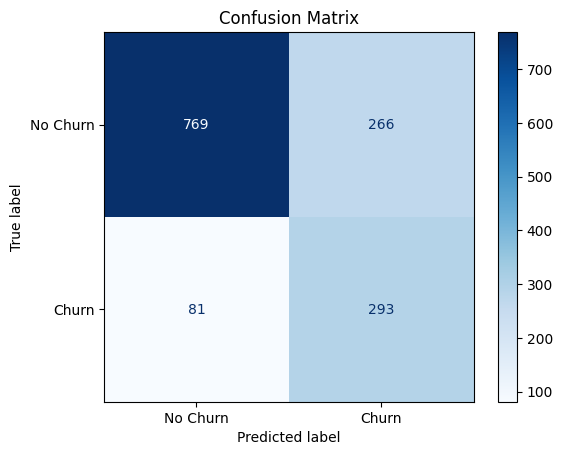

In [90]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [91]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob_best)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.8452


In [93]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [94]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [95]:
cv_results = cross_validate(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [96]:
cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary

,Metric,Mean,Std
0,Accuracy,0.763934,0.011424
1,Precision,0.538273,0.014852
2,Recall,0.774582,0.029734
3,F1 Score,0.635097,0.019552
4,ROC-AUC,0.844864,0.010745


In [97]:
fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1 Score": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

fold_results

,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.775510,0.553488,0.795987,0.652949,0.841064
1,2,0.744454,0.512941,0.729097,0.602210,0.828646
2,3,0.757764,0.530233,0.762542,0.625514,0.841044
3,4,0.771961,0.547085,0.816054,0.655034,0.857514
4,5,0.769982,0.547619,0.769231,0.639777,0.856054


In [99]:
from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/Customer Churn")
MODEL_DIR.mkdir(exist_ok=True)

print("Model directory created:", MODEL_DIR.resolve())

Model directory created: /content/drive/MyDrive/Customer Churn


In [100]:
import joblib

joblib.dump(
    best_model,
    MODEL_DIR / "customer_churn_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [101]:
loaded_pipeline = joblib.load(
    MODEL_DIR / "customer_churn_pipeline.pkl"
)

print(type(loaded_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [102]:
sample = X_test.iloc[:5]

loaded_predictions = loaded_pipeline.predict(sample)

print("Predictions:", loaded_predictions)

Predictions: [0 1 0 1 0]
